## For Colab Users
- If you are using Google Colab, run the following code cells to set up the environment and clone the repository.

In [ ]:
!git clone https://github.com/peunsu/wesad_stress_detection

In [ ]:
!pip install neurokit2 mne

In [ ]:
%cd /content/wesad_stress_detection/dual-branch-vae-lstm

## Setup

In [10]:
import warnings

def fxn():
    warnings.warn("deprecated", DeprecationWarning)

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    fxn()

In [11]:
import os
import json
import pickle
from itertools import product
from functools import partial

import numpy as np
import pandas as pd
import neurokit2 as nk
import matplotlib.pylab as plt
import scipy
import torch
import torch.optim as optim
from matplotlib.pyplot import savefig
from pathlib import Path
from tqdm import tqdm
from tqdm.contrib.concurrent import process_map

from models import VAE_LSTM_MA, VAE_LSTM_Linear, VAE_LSTM_Local, MA_VAE
from data_loader import DataGenerator
from utils import process_config, create_dirs, load_latest_vae_checkpoint, set_random_seeds

## WESAD Dataset
- Philip Schmidt, Attila Reiss, Robert Duerichen, Claus Marberger and Kristof Van Laerhoven, "Introducing WESAD, a multimodal dataset for Wearable Stress and Affect Detection", ICMI 2018, Boulder, USA, 2018.
- The WESAD dataset can be downloaded from [here](https://ubi29.informatik.uni-siegen.de/usi/data_wesad.html).
- Make sure to place the unzipped `WESAD` folder in the `dual-branch-vae-lstm/` directory.
- I recommend running the following code cells to download and unzip the dataset automatically.

### Download Dataset

In [3]:
!wget https://uni-siegen.sciebo.de/s/HGdUkoNlW1Ub0Gx/download/WESAD.zip

--2025-11-28 21:50:35--  https://uni-siegen.sciebo.de/s/HGdUkoNlW1Ub0Gx/download/WESAD.zip
Resolving uni-siegen.sciebo.de (uni-siegen.sciebo.de)... 128.176.1.4
Connecting to uni-siegen.sciebo.de (uni-siegen.sciebo.de)|128.176.1.4|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 2249444501 (2.1G) [application/zip]
Saving to: ‘WESAD.zip’

WESAD.zip           100%[===================>]   2.09G  14.5MB/s    in 2m 53s  

2025-11-28 21:53:29 (12.4 MB/s) - ‘WESAD.zip’ saved [2249444501/2249444501]



### Unzip Dataset

In [5]:
!unzip WESAD.zip -d .

Archive:  WESAD.zip
   creating: ./WESAD/S10/
  inflating: ./WESAD/S10/S10.pkl     
  inflating: ./WESAD/S10/S10_E4_Data.zip  
  inflating: ./WESAD/S10/S10_quest.csv  
  inflating: ./WESAD/S10/S10_readme.txt  
  inflating: ./WESAD/S10/S10_respiban.txt  
   creating: ./WESAD/S11/
  inflating: ./WESAD/S11/S11.pkl     
  inflating: ./WESAD/S11/S11_E4_Data.zip  
  inflating: ./WESAD/S11/S11_quest.csv  
  inflating: ./WESAD/S11/S11_readme.txt  
  inflating: ./WESAD/S11/S11_respiban.txt  
   creating: ./WESAD/S13/
  inflating: ./WESAD/S13/S13.pkl     
  inflating: ./WESAD/S13/S13_E4_Data.zip  
  inflating: ./WESAD/S13/S13_quest.csv  
  inflating: ./WESAD/S13/S13_readme.txt  
  inflating: ./WESAD/S13/S13_respiban.txt  
   creating: ./WESAD/S14/
  inflating: ./WESAD/S14/S14.pkl     
  inflating: ./WESAD/S14/S14_E4_Data.zip  
  inflating: ./WESAD/S14/S14_quest.csv  
  inflating: ./WESAD/S14/S14_readme.txt  
  inflating: ./WESAD/S14/S14_respiban.txt  
   creating: ./WESAD/S15/
  inflating: ./WES

### Clean up

In [6]:
!rm WESAD.zip

## Data Preprocessing

### Setup
- Set subject IDs for training and testing.
- Define the initial sample rates and target sample rates for resampling.

In [1]:
SUBJECT_IDS = [f'S{i}' for i in range(2, 12)] + [f'S{i}' for i in range(13, 18)]  # S2 to S11 and S13 to S17
SAMPLING_RATE = 4
SAMPLING_RATES = {
    'chest': {
        'ACC': 700,
        'ECG': 700,
        'EMG': 700,
        'EDA': 700,
        'Resp': 700,
        'Temp': 700
    },
    'wrist': {
        'ACC': 32,
        'BVP': 64,
        'EDA': 4,
        'TEMP': 4
    },
    'label': 700
}

### Signal Processing
- Resample the signals to a common frequency.
- Apply necessary filtering to the signals.
- Extract relevant features from the raw signals.
- [NeuroKit2](https://neuropsychology.github.io/NeuroKit/) library is used for signal processing tasks.
- First, define the functions for processing each signal type.

In [12]:
def ecg_process(ecg_signal, sampling_rate=1000, method="neurokit", **kwargs):
    # Sanitize and clean input
    ecg_signal = nk.signal.signal_sanitize(ecg_signal)
    ecg_cleaned = ecg_signal

    # Detect R-peaks
    instant_peaks, info = nk.ecg_peaks(
        ecg_cleaned=ecg_cleaned,
        sampling_rate=sampling_rate,
        method="rodrigues2021",
        correct_artifacts=True,
    )

    # Calculate heart rate
    rate = nk.signal.signal_rate(
        info, sampling_rate=sampling_rate, desired_length=len(ecg_cleaned)
    )

    # Assess signal quality
    quality = nk.ecg_quality(
        ecg_cleaned, rpeaks=info["ECG_R_Peaks"], sampling_rate=sampling_rate
    )

    # Merge signals in a DataFrame
    signals = pd.DataFrame(
        {
            "ECG_Raw": ecg_signal,
            "ECG_Clean": ecg_cleaned,
            "ECG_Rate": rate,
            "ECG_Quality": quality,
        }
    )

    # Delineate QRS complex
    delineate_signal, delineate_info = nk.ecg_delineate(
        ecg_cleaned=ecg_cleaned, rpeaks=info["ECG_R_Peaks"], sampling_rate=sampling_rate
    )
    info.update(delineate_info)  # Merge waves indices dict with info dict

    # Determine cardiac phases
    cardiac_phase = nk.ecg_phase(
        ecg_cleaned=ecg_cleaned,
        rpeaks=info["ECG_R_Peaks"],
        delineate_info=delineate_info,
    )

    # Add additional information to signals DataFrame
    signals = pd.concat(
        [signals, instant_peaks, delineate_signal, cardiac_phase], axis=1
    )

    # return signals DataFrame and R-peak locations
    return signals, info

In [13]:
def emg_process(emg_signal, sampling_rate=1000, report=None, **kwargs):
    # Sanitize input
    emg_signal = nk.signal.signal_sanitize(emg_signal)
    methods = nk.emg.emg_methods.emg_methods(sampling_rate=sampling_rate, **kwargs)

    # Clean signal
    emg_cleaned = emg_signal

    # Get amplitude
    amplitude = nk.emg_amplitude(emg_cleaned)

    # Get onsets, offsets, and periods of activity
    activity_signal, info = nk.emg_activation(
        emg_amplitude=amplitude,
        emg_cleaned=emg_cleaned,
        sampling_rate=sampling_rate,
        method=methods["method_activation"],
        **methods["kwargs_activation"]
    )
    info["sampling_rate"] = sampling_rate  # Add sampling rate in dict info

    # Prepare output
    signals = pd.DataFrame(
        {"EMG_Raw": emg_signal, "EMG_Clean": emg_cleaned, "EMG_Amplitude": amplitude}
    )

    signals = pd.concat([signals, activity_signal], axis=1)

    return signals, info


In [14]:
def eda_process(
    eda_signal, sampling_rate=1000, method="neurokit", report=None, **kwargs
):
    # Sanitize input
    eda_signal = nk.signal.signal_sanitize(eda_signal)
    methods = nk.eda.eda_methods.eda_methods(sampling_rate=sampling_rate, method=method, **kwargs)

    # Preprocess
    # Clean signal
    eda_cleaned = eda_signal
    if methods["method_phasic"] is None or methods["method_phasic"].lower() == "none":
        eda_decomposed = pd.DataFrame({"EDA_Phasic": eda_cleaned})
    else:
        eda_decomposed = nk.eda_phasic(
            eda_cleaned,
            sampling_rate=sampling_rate,
            method=methods["method_phasic"],
            **methods["kwargs_phasic"],
        )

    # Find peaks
    peak_signal, info = nk.eda_peaks(
        eda_decomposed["EDA_Phasic"].values,
        sampling_rate=sampling_rate,
        method=methods["method_peaks"],
        amplitude_min=0.1,
        **methods["kwargs_peaks"],
    )
    info["sampling_rate"] = sampling_rate  # Add sampling rate in dict info

    # Store
    signals = pd.DataFrame({"EDA_Raw": eda_signal, "EDA_Clean": eda_cleaned})

    signals = pd.concat([signals, eda_decomposed, peak_signal], axis=1)

    return signals, info

In [15]:
def rsp_process(
    rsp_signal,
    sampling_rate=1000,
    method="khodadad2018",
    method_rvt="harrison2021",
    report=None,
    **kwargs
):
    # Sanitize input
    rsp_signal = nk.misc.as_vector(rsp_signal)
    methods = nk.rsp.rsp_methods(
        sampling_rate=sampling_rate, method=method, method_rvt=method_rvt, **kwargs
    )

    # Clean signal
    rsp_cleaned = rsp_signal

    # Extract, fix and format peaks
    peak_signal, info = nk.rsp_peaks(
        rsp_cleaned,
        sampling_rate=sampling_rate,
        method=methods["method_peaks"],
        amplitude_min=0.3,
        **methods["kwargs_peaks"],
    )
    info["sampling_rate"] = sampling_rate  # Add sampling rate in dict info

    # Get additional parameters
    phase = nk.rsp_phase(peak_signal, desired_length=len(rsp_signal))
    amplitude = nk.rsp_amplitude(rsp_cleaned, peak_signal)
    rate = nk.signal.signal_rate(
        info["RSP_Troughs"], sampling_rate=sampling_rate, desired_length=len(rsp_signal)
    )
    symmetry = nk.rsp_symmetry(rsp_cleaned, peak_signal)
    rvt = nk.rsp_rvt(
        rsp_cleaned,
        method=methods["method_rvt"],
        sampling_rate=sampling_rate,
        silent=True,
    )

    # Prepare output
    signals = pd.DataFrame(
        {
            "RSP_Raw": rsp_signal,
            "RSP_Clean": rsp_cleaned,
            "RSP_Amplitude": amplitude,
            "RSP_Rate": rate,
            "RSP_RVT": rvt,
        }
    )
    signals = pd.concat([signals, phase, symmetry, peak_signal], axis=1)

    return signals, info


In [16]:
def ppg_process(
    ppg_signal, sampling_rate=1000, method="elgendi", method_quality="templatematch", report=None, **kwargs
):
    # Sanitize input
    ppg_signal = nk.misc.as_vector(ppg_signal)
    methods = nk.ppg.ppg_methods(sampling_rate=sampling_rate, method=method, method_quality=method_quality, **kwargs)

    # Clean signal
    ppg_cleaned = ppg_signal

    # Find peaks
    peaks_signal, info = nk.ppg_peaks(
        ppg_cleaned,
        sampling_rate=sampling_rate,
        method="bishop",
    )

    info["sampling_rate"] = sampling_rate  # Add sampling rate in dict info

    # Rate computation
    rate = nk.signal.signal_rate(
        info["PPG_Peaks"], sampling_rate=sampling_rate, desired_length=len(ppg_cleaned)
    )

    # Assess signal quality
    quality = nk.ppg_quality(
        ppg_cleaned,
        peaks=info["PPG_Peaks"],
        sampling_rate=sampling_rate,
        method=methods["method_quality"],
        **methods["kwargs_quality"]
    )

    # Prepare output
    signals = pd.DataFrame(
        {
            "PPG_Raw": ppg_signal,
            "PPG_Clean": ppg_cleaned,
            "PPG_Rate": rate,
            "PPG_Quality": quality,
            "PPG_Peaks": peaks_signal["PPG_Peaks"].values,
        }
    )

    return signals, info


- Process signals for each subject.

In [17]:
def load_data(subject_id: str, path: str, sampling_rate: int = 4):
    data_path = Path(path) / subject_id / f'{subject_id}.pkl'
    with open(data_path, 'rb') as file:
        data = pickle.load(file, encoding='latin1')
    
    data_chest = data['signal']['chest']
    data_wrist = data['signal']['wrist']
    data_label = data['label']
    
    for key in data_chest.keys():
        if key == 'ACC':
            # ACC has 3 channels, so we need to resample each channel separately
            temp = []
            for i in range(data_chest[key].shape[1]):
                resampled = nk.signal_resample(data_chest[key][:, i], sampling_rate=SAMPLING_RATES['chest'][key], desired_sampling_rate=sampling_rate)
                filtered = nk.signal_filter(resampled, sampling_rate=sampling_rate, lowcut=0.4, method='fir')
                temp.append(filtered)
            data_chest[key] = np.linalg.norm(np.array(temp), axis=0)
        else:
            resampled = nk.signal_resample(data_chest[key][:, 0], sampling_rate=SAMPLING_RATES['chest'][key], desired_sampling_rate=sampling_rate)
            data_chest[key] = resampled
    for key in data_wrist.keys():
        if key == 'ACC':
            # ACC has 3 channels, so we need to resample each channel separately
            temp = []
            for i in range(data_wrist[key].shape[1]):
                temp.append(nk.signal_resample(data_wrist[key][:, i], sampling_rate=SAMPLING_RATES['wrist'][key], desired_sampling_rate=sampling_rate))
            data_wrist[key] = np.linalg.norm(np.array(temp), axis=0)
        else:
            resampled = nk.signal_resample(data_wrist[key][:, 0], sampling_rate=SAMPLING_RATES['wrist'][key], desired_sampling_rate=sampling_rate)
            data_wrist[key] = resampled

    if SAMPLING_RATES['label'] > sampling_rate:
        data_label = data_label[::SAMPLING_RATES['label'] // sampling_rate]
    elif SAMPLING_RATES['label'] < sampling_rate:
        time = np.round(np.arange(0, len(data_label)) / SAMPLING_RATES['label'], 3)
        f = scipy.interpolate.interp1d(time, data_label, kind='nearest', fill_value='extrapolate')
        time_new = np.arange(0, time[-1], 1 / sampling_rate)
        data_label = f(time_new)

    ecg_chest, _ = ecg_process(data_chest['ECG'], sampling_rate=sampling_rate)
    emg_chest, _ = emg_process(data_chest['EMG'], sampling_rate=sampling_rate)
    eda_chest, _ = eda_process(data_chest['EDA'], sampling_rate=sampling_rate)
    resp_chest, _ = rsp_process(data_chest['Resp'], sampling_rate=sampling_rate)
    
    bvp_wrist, _ = ppg_process(data_wrist['BVP'], sampling_rate=sampling_rate)
    eda_wrist, _ = eda_process(data_wrist['EDA'], sampling_rate=sampling_rate)
    
    acc_chest = pd.DataFrame(data_chest['ACC'], columns=['ACC_chest'])
    ecg_chest = ecg_chest.drop(columns=['ECG_Raw', 'ECG_Clean']).add_suffix('_chest')
    emg_chest = emg_chest.drop(columns=['EMG_Raw', 'EMG_Clean']).add_suffix('_chest')
    eda_chest = eda_chest.drop(columns=['EDA_Raw', 'EDA_Clean']).add_suffix('_chest')
    resp_chest = resp_chest.drop(columns=['RSP_Raw', 'RSP_Clean']).add_suffix('_chest')
    temp_chest = pd.DataFrame(data_chest['Temp'], columns=['Temp_chest'])

    acc_wrist = pd.DataFrame(data_wrist['ACC'], columns=['ACC_wrist'])
    bvp_wrist = bvp_wrist.drop(columns=['PPG_Raw', 'PPG_Clean']).add_suffix('_wrist')
    eda_wrist = eda_wrist.drop(columns=['EDA_Raw', 'EDA_Clean']).add_suffix('_wrist')
    temp_wrist = pd.DataFrame(data_wrist['TEMP'], columns=['TEMP_wrist'])

    label = pd.DataFrame(data_label, columns=['label'])
    
    # Merge all dataframes on their time indices
    df = pd.concat([acc_chest, ecg_chest, emg_chest, eda_chest, resp_chest, temp_chest,
                    acc_wrist, bvp_wrist, eda_wrist, temp_wrist, label], axis=1, join='outer')
    
    # Filter labels to include only 1 (baseline), 2 (stress), and 3 (amusement)
    df = df[df['label'].isin([1, 2, 3])]
    
    # Reset index to have a clean integer index
    df.reset_index(drop=True, inplace=True)
    
    for col in df.columns:
        if np.array_equal(df[col].unique(), np.array([0., 1.])):
            df[col] = df[col].astype(int)
    
    df = df.assign(
        subject_id=subject_id,
        label = df['label'].map({1: 0, 2: 1, 3: 0}) # Binary classification: 0 (non-stress), 1 (stress)
    )
    
    return df

- The function below processes signals for all subjects with multiprocessing to speed up the computation.

In [18]:
def load_all_data(subject_ids: list, path: str, sampling_rate: int = 4):
    all_data = {}
    
    df_output = process_map(
        partial(load_data, path=path, sampling_rate=sampling_rate),
        subject_ids,
        max_workers=4
    )
    
    for subject_id, df_subject in zip(subject_ids, df_output):
        all_data[subject_id] = df_subject
    
    print('All data loaded')
    
    return all_data

- The function below splits the processed data into training and testing sets based on subject IDs.

In [19]:
def data_split(all_data, test_subjects: np.array):
    df_train = pd.concat(
        [all_data[subject_id] for subject_id in all_data if subject_id not in test_subjects],
        ignore_index=True,
        axis=0
    )
    
    df_test = pd.concat(
        [all_data[subject_id] for subject_id in test_subjects],
        ignore_index=True,
        axis=0
    )
    
    df_train = df_train[df_train['label'] == 0].reset_index(drop=True) # Use only non-stress data for training 
    df_test = df_test.reset_index(drop=True) # Use all data for testing
    
    df_train.ffill(inplace=True)
    df_test.ffill(inplace=True)
    
    print('Data split into train and test sets')
    print('Train data shape:', df_train.shape)
    print('Test data shape:', df_test.shape)

    return df_train, df_test

- Load and preprocess the WESAD dataset using the defined functions.
- It takes some time to process all the signals.

In [20]:
all_data = load_all_data(SUBJECT_IDS, 'WESAD', SAMPLING_RATE)

  0%|          | 0/15 [00:00<?, ?it/s]

/home/peunsu/ml_project/venv/lib/python3.10/site-packages/neurokit2/events/events_find.py:152: NeuroKitWarning: No events found. Check your event_channel or adjust 'threshold' or 'keep' arguments.
  warn(
/home/peunsu/ml_project/venv/lib/python3.10/site-packages/neurokit2/events/events_find.py:152: NeuroKitWarning: No events found. Check your event_channel or adjust 'threshold' or 'keep' arguments.
  warn(
/home/peunsu/ml_project/venv/lib/python3.10/site-packages/neurokit2/events/events_find.py:152: NeuroKitWarning: No events found. Check your event_channel or adjust 'threshold' or 'keep' arguments.
  warn(


All data loaded


- For k-fold cross-validation, split the subjects into k folds (k=3).

In [21]:
subject_k_fold = np.array_split(SUBJECT_IDS, 3)
subject_k_fold

[array(['S2', 'S3', 'S4', 'S5', 'S6'], dtype='<U3'),
 array(['S7', 'S8', 'S9', 'S10', 'S11'], dtype='<U3'),
 array(['S13', 'S14', 'S15', 'S16', 'S17'], dtype='<U3')]

- Split the data into training and testing sets.
- Save the preprocessed data to `.csv` files for later use.

In [23]:
Path('data').mkdir(parents=True, exist_ok=True)
for i, test_subjects in enumerate(subject_k_fold):
    df_train, df_test = data_split(all_data, test_subjects)
    df_train.to_csv(f'data/train_fold{i}.csv', index=False)
    df_test.to_csv(f'data/test_fold{i}.csv', index=False)
    print('df_train: %s', df_train.label.value_counts().to_dict())
    print('df_test: %s', df_test.label.value_counts().to_dict())
    print(f'Saved train_fold{i}.csv and test_fold{i}.csv')

Data split into train and test sets
Train data shape: (62044, 57)
Test data shape: (43440, 57)
df_train: %s {0: 62044}
df_test: %s {0: 30700, 1: 12740}
Saved train_fold0.csv and test_fold0.csv
Data split into train and test sets
Train data shape: (61748, 57)
Test data shape: (44436, 57)
df_train: %s {0: 61748}
df_test: %s {0: 30996, 1: 13440}
Saved train_fold1.csv and test_fold1.csv
Data split into train and test sets
Train data shape: (61696, 57)
Test data shape: (44732, 57)
df_train: %s {0: 61696}
df_test: %s {0: 31048, 1: 13684}
Saved train_fold2.csv and test_fold2.csv


### Data Loader (PyTorch)
- The Data Loader is implemented in `data_loader.py` file. See the implementation for details.
- It loads the preprocessed `.csv` files and prepares the data for training and evaluation.
- The data loader handles normalization, windowing, batching, and shuffling of the data.
- It also splits the train set into train and validation sets.

## Train (3-Fold CV, Changing model and hyperparameters)

- Train models with 3-Fold Cross Validation while changing model types and hyperparameters.
- Save the trained models and training logs for later evaluation. (`experiments/` directory)
- The codes below take very very long time to run all experiments.
- If you want to train specific model with specific hyperparameters, edit `config.json` and run the code below in Jupyter Notebook cell.
  - `!python train.py --config config.json`
- See train code implementation in `train.py` for more details.

### Train for VAE-LSTM families (3 * 5 * 3 = 45 experiments)
- Train VAE-LSTM based models with 3-Fold Cross Validation while changing model types and hyperparameters.
- `latent_dim` and `batch_size` are fixed to 12 and 512, respectively.

In [73]:
grid = {
    'exp_name': [
        'vae-lstm-dual-ma',
        'vae-lstm-dual-linear',
        'vae-lstm-local-only',
    ],
    'window_size': [
        (576, 48),
        (288, 48),
        (288, 24),
        (144, 24),
        (72, 24)
    ],
    'fold_id': [0, 1, 2]
}
grid_prod = list(product(*grid.values()))
len(grid_prod)

45

In [ ]:
for exp_name, window_size, fold_id in tqdm(grid_prod, desc="Experiments"):
    with open('config.json', 'r', encoding='utf-8') as f:
        config = json.load(f)
    config['exp_name'] = exp_name
    config['window_size'] = window_size[0]
    config['small_window_size'] = window_size[1]
    config['fold_id'] = fold_id
    config['window_shift'] = 1
    config['latent_dim'] = 12
    config['batch_size'] = 512
    json.dump(config, open('config.json', 'w', encoding='utf-8'), indent=4)

    !python train.py --config config.json

### Train for MA-VAE (5 * 3 = 15 experiments)
- Train MA-VAE model with 3-Fold Cross Validation while changing hyperparameters.
- `latent_dim` and `batch_size` are fixed to 64 and 64, respectively.

In [ ]:
grid = {
    'exp_name': [
        'ma-vae',
    ],
    'window_size': [
        (576, 48),
        (288, 48),
        (288, 24),
        (144, 24),
        (72, 24)
    ],
    'fold_id': [0, 1, 2]
}
grid_prod = list(product(*grid.values()))
len(grid_prod)

In [ ]:
for exp_name, window_size, fold_id in tqdm(grid_prod, desc="Experiments"):
    with open('config.json', 'r', encoding='utf-8') as f:
        config = json.load(f)
    config['exp_name'] = exp_name
    config['window_size'] = window_size[0]
    config['small_window_size'] = window_size[0]
    config['window_shift'] = window_size[1]
    config['fold_id'] = fold_id
    config['latent_dim'] = 64
    config['batch_size'] = 64
    json.dump(config, open('config.json', 'w', encoding='utf-8'), indent=4)

    !python train.py --config config.json

## Test (3-Fold CV, All trained models)
- Evaluate all trained models using test dataset.
- Evaluate and save the metrics to `experiments/(...)/result/test_results.json`.
- If you want to test specific model with specific hyperparameters, edit `config.json` and run the code below in Jupyter Notebook cell.
  - `!python test.py --config config.json`
  - Make sure that your current directory is `dual-branch-vae-lstm/`
- See test code implementation in `test.py` for more details.

### Test for VAE-LSTM families (45 checkpoints)
- Test all trained VAE-LSTM based models (45 checkpoints) using test dataset.

In [ ]:
grid = {
    'exp_name': [
        'vae-lstm-dual-ma',
        'vae-lstm-dual-linear',
        'vae-lstm-local-only',
    ],
    'window_size': [
        (576, 48),
        (288, 48),
        (288, 24),
        (144, 24),
        (72, 24)
    ],
    'fold_id': [0, 1, 2]
}
grid_prod = list(product(*grid.values()))
len(grid_prod)

In [ ]:
for exp_name, window_size, fold_id in tqdm(grid_prod, desc="Experiments"):
    with open('config.json', 'r', encoding='utf-8') as f:
        config = json.load(f)
    config['exp_name'] = exp_name
    config['window_size'] = window_size[0]
    config['small_window_size'] = window_size[1]
    config['fold_id'] = fold_id
    config['window_shift'] = 1
    config['latent_dim'] = 12
    config['batch_size'] = 512
    json.dump(config, open('config.json', 'w', encoding='utf-8'), indent=4)

    !python test.py --config config.json

### Test for MA-VAE (15 checkpoints)
- Test all trained MA-VAE models (15 checkpoints) using test dataset.

In [ ]:
grid = {
    'exp_name': [
        'ma-vae',
    ],
    'window_size': [
        (576, 48),
        (288, 48),
        (288, 24),
        (144, 24),
        (72, 24)
    ],
    'fold_id': [0, 1, 2]
}
grid_prod = list(product(*grid.values()))
len(grid_prod)

In [ ]:
for exp_name, window_size, fold_id in tqdm(grid_prod, desc="Experiments"):
    with open('config.json', 'r', encoding='utf-8') as f:
        config = json.load(f)
    config['exp_name'] = exp_name
    config['window_size'] = window_size[0]
    config['small_window_size'] = window_size[0]
    config['window_shift'] = window_size[1]
    config['fold_id'] = fold_id
    config['latent_dim'] = 64
    config['batch_size'] = 64
    json.dump(config, open('config.json', 'w', encoding='utf-8'), indent=4)

    !python test.py --config config.json

## Anomaly Detection with Visualization for Specific Trained Model
- Load a specific trained model checkpoint and perform anomaly detection on test dataset.
- Visualize the reconstruction results and anomaly scores.
- The codes below are not necessary for running and evaluating the models, but may used for further analysis and visualization.

### Preparation
- Set up the environment and load the dataset.
- Load the trained model checkpoint.

In [46]:
os.environ["CUDA_DEVICE_ORDER"] = "PCI_BUS_ID"   # keep GPU ordering consistent
os.environ["CUDA_VISIBLE_DEVICES"] = "0"

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda:0


In [47]:
# load VAE model
config = process_config('config.json')
# create the experiments dirs
create_dirs([config['result_dir'], config['checkpoint_dir']])
# create your data generator
data = DataGenerator(config)

In [48]:
seed = config.get('random_seed', 42)
set_random_seeds(seed)

In [49]:
if config['load_dir'] == 'default' or config['load_dir'] == 'experiments':
    data_dir = Path('data')
    fold_id = config.get('fold_id', 0)
    test_df = pd.read_csv(data_dir / f'test_fold{fold_id}.csv')
else:
    raise ValueError("Invalid load_dir in config.json")

test_subjects = test_df.pop('subject_id')
test_labels = test_df.pop('label')

train_loader, val_loader, test_loader = data.get_dataloaders(test=True)

In [50]:
# create a VAE model and load the latest checkpoint
if config['exp_name'] == 'vae-lstm-dual-ma':
    model = VAE_LSTM_MA(config, beta=1e-8).to(device)
    optimizer = optim.Adam(model.parameters(), lr=0.0004, betas=(0.9, 0.95))
elif config['exp_name'] == 'vae-lstm-dual-linear':
    model = VAE_LSTM_Linear(config, beta=1e-8).to(device)
    optimizer = optim.Adam(model.parameters(), lr=0.0004, betas=(0.9, 0.95))
elif config['exp_name'] == 'vae-lstm-local-only':
    model = VAE_LSTM_Local(config, beta=1e-8).to(device)
    optimizer = optim.Adam(model.parameters(), lr=0.0004, betas=(0.9, 0.95))
elif config['exp_name'] == 'ma-vae':
    model = MA_VAE(config, beta=1e-8).to(device)
    optimizer = optim.Adam(model.parameters(), amsgrad=True)
else:
    raise ValueError(f"Unknown experiment name: {config['exp_name']}")

if not load_latest_vae_checkpoint(model, optimizer, device, config['checkpoint_dir']):
    raise RuntimeError("No checkpoint found to load.")
model.eval()

Loaded VAE checkpoint: experiments/vae-lstm-dual-ma/fold-2-batch-512/vae-lstm-dual-ma-576-48-1-12/checkpoint/vae_checkpoint_epoch_99.pth


VAE_LSTM_MA(
  (encoder): VAE_Encoder(
    (local_module): LocalModule(
      (enc_conv1): Sequential(
        (0): Conv2d(55, 64, kernel_size=(3, 1), stride=(2, 1), padding=(1, 0))
        (1): LeakyReLU(negative_slope=0.2)
      )
      (enc_conv2): Sequential(
        (0): Conv2d(64, 128, kernel_size=(3, 1), stride=(2, 1), padding=(1, 0))
        (1): LeakyReLU(negative_slope=0.2)
      )
      (enc_conv3): Sequential(
        (0): Conv2d(128, 256, kernel_size=(3, 1), stride=(2, 1), padding=(1, 0))
        (1): LeakyReLU(negative_slope=0.2)
      )
      (enc_conv4): Sequential(
        (0): Conv2d(256, 512, kernel_size=(6, 1), stride=(1, 1))
        (1): LeakyReLU(negative_slope=0.2)
      )
      (enc_fc): Sequential(
        (0): Linear(in_features=512, out_features=48, bias=True)
        (1): LeakyReLU(negative_slope=0.2)
      )
    )
    (global_module): GlobalModule(
      (enc_conv1): Sequential(
        (0): Conv1d(55, 64, kernel_size=(7,), stride=(3,), padding=(3,))
      

### Model parameters

In [51]:
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'The model has {count_parameters(model):,} trainable parameters')

The model has 2,250,175 trainable parameters


### Evaluate anomaly scores for datasets
- Evaluate and visualize anomaly scores for train, validation, and test datasets.
- Anomaly scores are calculated based on reconstruction errors.
- Also calculate the inference time for each dataset.

In [52]:
def evaluate_model(data_loader):
    batch_recons_error = []
    elapsed_times = []
    
    for batch_data in tqdm(data_loader, desc="Evaluating"):
        if isinstance(batch_data, (list, tuple)):
            batch_data = batch_data[0]
        batch_data = batch_data.to(device)
        
        start_event = torch.cuda.Event(enable_timing=True)
        end_event = torch.cuda.Event(enable_timing=True)
        
        with torch.no_grad():
            start_event.record() # Start timing
            
            reconstruction = model(batch_data)
            Xhat = reconstruction[0]
                        
            batch_data = batch_data.view(Xhat.size(0), -1, Xhat.size(2), Xhat.size(3))
            batch_data = batch_data[:, 1:, :, :]  # Align batch_data with the number of windows
            
            recon_loss = torch.sum((batch_data - Xhat).pow(2), dim=[1, 2, 3])
            
            end_event.record() # End timing
            torch.cuda.synchronize()
            
            batch_recons_error.append(recon_loss.cpu().numpy())
            elapsed_times.append(start_event.elapsed_time(end_event))
    
    batch_recons_error = np.concatenate(batch_recons_error, axis=0)
    elapsed_time = sum(elapsed_times)
    
    return batch_recons_error, elapsed_time

def evaluate_model_ma_vae(data_loader):
    batch_recons_error = []
    elapsed_times = []
    
    for batch_data in tqdm(data_loader, desc="Evaluating"):
        if isinstance(batch_data, (list, tuple)):
            batch_data = batch_data[0]
        batch_data = batch_data.to(device)
        
        start_event = torch.cuda.Event(enable_timing=True)
        end_event = torch.cuda.Event(enable_timing=True)
        
        with torch.no_grad():
            start_event.record() # Start timing
            
            reconstruction = model(batch_data)
            Xhat = reconstruction[2]
            
            recon_loss = torch.sum((batch_data - Xhat).pow(2), dim=(1,2))
            
            end_event.record() # End timing
            torch.cuda.synchronize()
            
            batch_recons_error.append(recon_loss.cpu().numpy())
            elapsed_times.append(start_event.elapsed_time(end_event))
    
    batch_recons_error = np.concatenate(batch_recons_error, axis=0)
    elapsed_time = sum(elapsed_times)
    
    return batch_recons_error, elapsed_time

In [53]:
def plot_histogram(test_anomaly_metric, n_bins, title, saveplot=False):
    test_anomaly_list = np.squeeze(np.ndarray.flatten(test_anomaly_metric))
    his = plt.hist(test_anomaly_list, bins=n_bins, density=True)
    plt.title(title)
    plt.xlabel('anomaly score value')
    plt.ylabel('density')
    plt.xlim(0, np.amax(test_anomaly_list))
    if saveplot:
        savefig(config['result_dir']+'reconstruction_error_histogram.pdf')
    else:
        plt.show()

- Evaluate anomaly scores for train set and visualize the reconstruction error distribution.

In [54]:
if config['exp_name'] == 'ma-vae':
    train_score, elapsed_time = evaluate_model_ma_vae(train_loader)
else:
    train_score, elapsed_time = evaluate_model(train_loader)
print(f"Train Set Inference Time: {elapsed_time:.2f} ms")

Evaluating: 100%|██████████| 99/99 [00:04<00:00, 20.73it/s]

Train Set Inference Time: 1486.78 ms


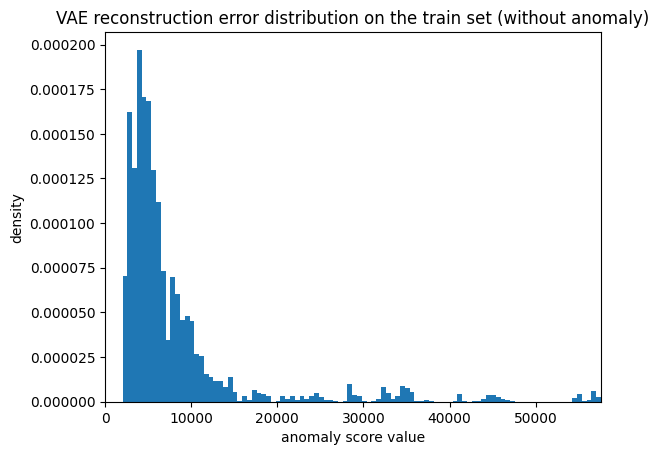

In [55]:
plot_histogram(train_score, 100, 'VAE reconstruction error distribution on the train set (without anomaly)')

- Evaluate anomaly scores for validation set and visualize the reconstruction error distribution.

In [56]:
if config['exp_name'] == 'ma-vae':
    val_score, elapsed_time = evaluate_model_ma_vae(val_loader)
else:
    val_score, elapsed_time = evaluate_model(val_loader)
print(f"Validation Set Inference Time: {elapsed_time:.2f} ms")

Evaluating: 100%|██████████| 11/11 [00:00<00:00, 21.90it/s]

Validation Set Inference Time: 143.77 ms


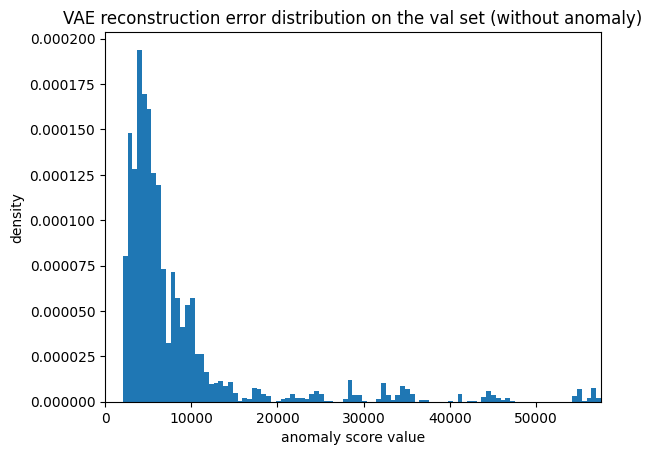

In [57]:
plot_histogram(val_score, 100, 'VAE reconstruction error distribution on the val set (without anomaly)')

- Evaluate anomaly scores for test set and visualize the reconstruction error distribution.

In [58]:
if config['exp_name'] == 'ma-vae':
    test_score, elapsed_time = evaluate_model_ma_vae(test_loader)
else:
    test_score, elapsed_time = evaluate_model(test_loader)
print(f"Test Set Inference Time: {elapsed_time:.2f} ms")

Evaluating: 100%|██████████| 87/87 [00:03<00:00, 25.16it/s]

Test Set Inference Time: 908.06 ms


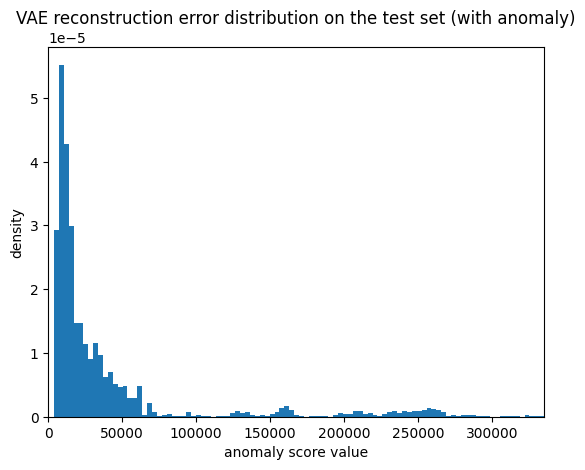

In [59]:
plot_histogram(test_score, 100, 'VAE reconstruction error distribution on the test set (with anomaly)')

### Preprocess Labels
- Preprocess the labels to match the windowed data used for anomaly detection.

In [60]:
idx_anomaly_test = test_labels[test_labels == 1].index.to_numpy()
n_test = len(data.test_set)
test_labels_vae = np.zeros(n_test)
anomaly_index_vae = []
for i in range(len(idx_anomaly_test)):
    idx_start = (idx_anomaly_test[i] - config['window_size']) // config['window_shift']
    idx_end = idx_anomaly_test[i] // config['window_shift'] + 1
    
    if idx_start < 0:
        idx_start = 0
    
    if idx_end > n_test:
        idx_end = n_test
    
    anomaly_index_vae.append(np.arange(idx_start,idx_end))
    test_labels_vae[idx_start:idx_end] = 1

### Find Theoretical Best Threshold
- Find the theoretical best threshold for anomaly detection.
- Calculate F1-score for various thresholds and find the threshold that gives the best F1-score.

In [61]:
def return_anomaly_idx_by_threshold(test_anomaly_metric, threshold):
    idx_error = np.flatnonzero(test_anomaly_metric > threshold)
    if len(idx_error.shape) == 0:
        idx_error = np.expand_dims(idx_error, 0)
    return idx_error

In [62]:
def augment_detected_idx(idx_detected_anomaly, anomaly_index):
    idx_detected_anomaly_set = set(idx_detected_anomaly)
    idx_detected_anomaly_extended = set(idx_detected_anomaly)
    
    # anomaly_index는 이상 구간(리스트의 리스트)이라고 가정
    for anomaly_win in anomaly_index:
        # 현재 이상 구간(anomaly_win)이 기존 탐지에 포함되었는지 확인
        # set intersection이 빠름
        if idx_detected_anomaly_set.intersection(anomaly_win):
            # 포함되었다면 해당 구간 전체를 확장된 set에 추가
            idx_detected_anomaly_extended.update(anomaly_win)

    # numpy로 변환 후 정렬
    return np.sort(np.array(list(idx_detected_anomaly_extended), dtype=int))

In [63]:
def count_TP_FP_FN(idx_detected_anomaly, anomaly_index, test_labels):  
    detected_labels = test_labels[idx_detected_anomaly]
    n_TP = np.sum(detected_labels == 1)
    n_FP = np.sum(detected_labels == 0)
    n_TN = np.sum(test_labels == 0) - n_FP
    n_FN = np.sum(test_labels == 1) - n_TP
    
    return n_TP, n_TN, n_FP, n_FN

In [64]:
def compute_precision_and_recall(idx_detected_anomaly, anomaly_index, test_labels):
    n_TP, n_TN, n_FP, n_FN = count_TP_FP_FN(idx_detected_anomaly, anomaly_index, test_labels)
    
    precision = n_TP / (n_TP + n_FP) if (n_TP + n_FP) > 0 else 1.0
    recall = n_TP / (n_TP + n_FN) if (n_TP + n_FN) > 0 else 0.0
    accuracy = (n_TP + n_TN) / (n_TP + n_FP + n_FN + n_TN) if (n_TP + n_FP + n_FN + n_TN) > 0 else 0.0
    F1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0.0
    
    return precision, recall, accuracy, F1, n_TP, n_TN, n_FP, n_FN

In [65]:
percentile_list = np.arange(0, 100.1, 1)
threshold_list = np.percentile(test_score, percentile_list)

n_threshold = len(threshold_list)

precision_aug = np.zeros(n_threshold)
recall_aug = np.zeros(n_threshold)
accuracy_aug = np.zeros(n_threshold)
F1_aug = np.zeros(n_threshold)

for i, threshold in tqdm(enumerate(threshold_list)):
    # augment the detection using the ground truth labels
    # a method to discount the factor one anomaly appears in multiple consecutive windows
    # introduced in "Unsupervised anomaly detection via variational auto-encoder for seasonal kpis in web applications"
    idx_detection_vae = return_anomaly_idx_by_threshold(test_score, threshold)
    idx_detection_vae_augmented = augment_detected_idx(idx_detection_vae, anomaly_index_vae)
    precision_aug[i], recall_aug[i], accuracy_aug[i], F1_aug[i], _, _, _, _ = compute_precision_and_recall(idx_detection_vae_augmented, 
                                                                                       anomaly_index_vae, 
                                                                                       test_labels_vae)

101it [00:52,  1.93it/s]


In [66]:
print("Best F1 score is {}".format(np.amax(F1_aug)))
idx_best_threshold = np.squeeze(np.argmax(F1_aug))
print("Best threshold is {}".format(threshold_list[idx_best_threshold]))
print("Precision is {}, recall is {}, accuracy is {}".format(precision_aug[idx_best_threshold], recall_aug[idx_best_threshold], accuracy_aug[idx_best_threshold]))

Best F1 score is 0.8371854719344187
Best threshold is 31856.48359374998
Precision is 0.768218147625764, recall is 0.919757333166552, accuracy is 0.8704622143714473


### Evaluate the model with metrics
- Evaluate the model using precision, recall, accuracy, and F1-score based on the best threshold found earlier.

In [67]:
# Now select a threshold
threshold = threshold_list[np.squeeze(np.argmax(F1_aug))]

print("Threshold: {}".format(threshold))
idx_detection = return_anomaly_idx_by_threshold(test_score, threshold)
idx_detection_augmented = augment_detected_idx(idx_detection, anomaly_index_vae)
precision, recall, accuracy, F1, n_TP, n_TN, n_FP, n_FN = compute_precision_and_recall(idx_detection_augmented, 
                                                                       anomaly_index_vae, 
                                                                       test_labels_vae)
print("Precision: {}".format(precision))
print("Recall: {}".format(recall))
print("Accuracy: {}".format(accuracy))
print("F1: {}".format(F1))
print("TP: {}".format(n_TP))
print("TN: {}".format(n_TN))
print("FP: {}".format(n_FP))
print("FN: {}".format(n_FN))

Threshold: 31856.48359374998
Precision: 0.768218147625764
Recall: 0.919757333166552
Accuracy: 0.8704622143714473
F1: 0.8371854719344187
TP: 14706
TN: 23731
FP: 4437
FN: 1283


### Visualize detection results

In [68]:
def slice_detected_indices_into_seq(idx_detection, interval): # interval: max gap between consecutive indices in a sequence
    detected_seq = []
    i = 0
    while i < len(idx_detection):
        if i == 0:
            cur_seq = [idx_detection[i]]
            i = i + 1
        else:
            if idx_detection[i] - idx_detection[i-1] > interval:
                detected_seq.append(cur_seq)
                cur_seq = [idx_detection[i]]
            else:
                cur_seq.append(idx_detection[i])
                if i == len(idx_detection) - 1:
                    detected_seq.append(cur_seq)
            i = i + 1
    
    print("Detected {} sequences".format(len(detected_seq)))
    return detected_seq

In [69]:
def plot_detected_anomalies(idx_detection, config, result, detection_method, augmented_flag=1, y_scale=5, y_lim=None):
    interval = config['window_size'] // config['window_shift']
    detected_seq = slice_detected_indices_into_seq(idx_detection, interval=interval)
    t_test = result['t_test']
    test = result['test']
    idx_anomaly_test = result['idx_anomaly_test']
        
    # plot detected sequences
    fig, axs = plt.subplots(1, 1, figsize=(18, 5), edgecolor='k')
    fig.subplots_adjust(hspace=.4, wspace=.4)
    axs.plot(t_test, test[:, 0]) # plot only the first channel
    for j in range(len(idx_anomaly_test)):
        if j == 0:
            axs.plot(idx_anomaly_test[j] * np.ones(20), np.linspace(0.8 * y_scale, y_scale, 20), 'r-', label='true anomalies')
        else:
            axs.plot(idx_anomaly_test[j] * np.ones(20), np.linspace(0.8 * y_scale, y_scale, 20), 'r-')
        
    for i in range(len(detected_seq)):
        for j in detected_seq[i]:
            if j == detected_seq[0][0]:
                axs.plot((j * config['window_shift'] + config['window_size']) * np.ones(20), np.linspace(-y_scale, -0.8*y_scale, 20), 'g-', label='detected anomalies')
            else:
                axs.plot((j * config['window_shift'] + config['window_size']) * np.ones(20), np.linspace(-y_scale, -0.8*y_scale, 20), 'g-')

    for j in range(len(idx_anomaly_test)):
        axs.plot(idx_anomaly_test[j] * np.ones(20), np.linspace(0.8 * y_scale, y_scale, 20), 'r--')

    for i in range(len(detected_seq)):
        interval_x = np.asarray([detected_seq[i][0] * config['window_shift'], detected_seq[i][-1] * config['window_shift'] + config['window_size']])
        interval_y = np.asarray([y_scale,y_scale])
        if i == 0:
            axs.fill_between(interval_x, interval_y, alpha=0.2, color='y', label='detected anomaly windows')
        else:
            axs.fill_between(interval_x, interval_y, alpha=0.2, color='y')
        interval_y = np.asarray([-y_scale,-y_scale])
        axs.fill_between(interval_x, interval_y, alpha=0.2, color='y')
    axs.grid(True)
    axs.set_xlim(0, len(t_test))
    if y_lim is None:
        axs.set_ylim(-y_scale, y_scale)
    else:
        axs.set_ylim(-y_scale, y_lim)
    axs.set_xlabel("timestamp (every {})".format(result['t_unit']))
    axs.set_title(f"dataset test sequence\n Detection method: {detection_method}")
    axs.legend()
    savefig(config['result_dir']+'detected_anomalies_{}_aug_{}.pdf'.format(detection_method, augmented_flag))

In [70]:
result = {}
result['t_test'] = test_df.index.values
result['test'] = test_df.values
result['t_unit'] = '0.25 sec'
result['idx_anomaly_test'] = np.flatnonzero(test_labels.values == 1)

- Visualize the detection results on test dataset.
- It may takes some time to plot all the figures.

Detected 9 sequences


/tmp/ipykernel_55171/1492443606.py:46: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  savefig(config['result_dir']+'detected_anomalies_{}_aug_{}.pdf'.format(detection_method, augmented_flag))
/tmp/ipykernel_55171/1492443606.py:46: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  savefig(config['result_dir']+'detected_anomalies_{}_aug_{}.pdf'.format(detection_method, augmented_flag))
/home/peunsu/ml_project/venv/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


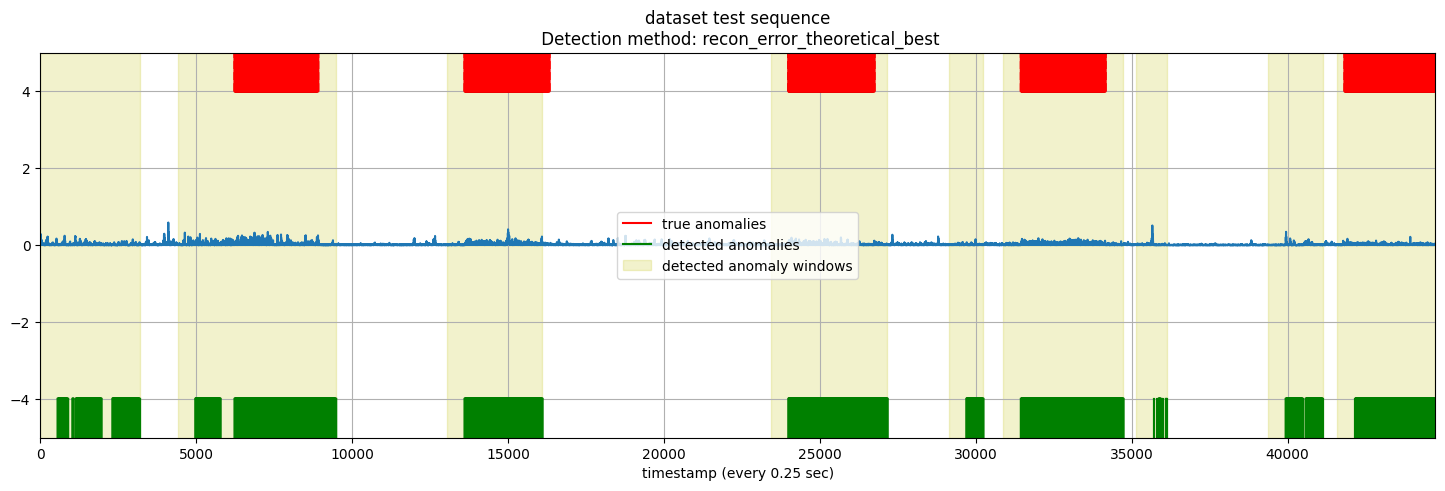

In [71]:
plot_detected_anomalies(idx_detection_augmented, 
                        config=config,
                        result=result, 
                        detection_method='recon_error_theoretical_best',
                        augmented_flag=1,
                        y_scale=5,
                        y_lim=5)

- Visualize the anomaly scores and ground truth labels.
- Threshold is plotted as a horizontal dashed line.

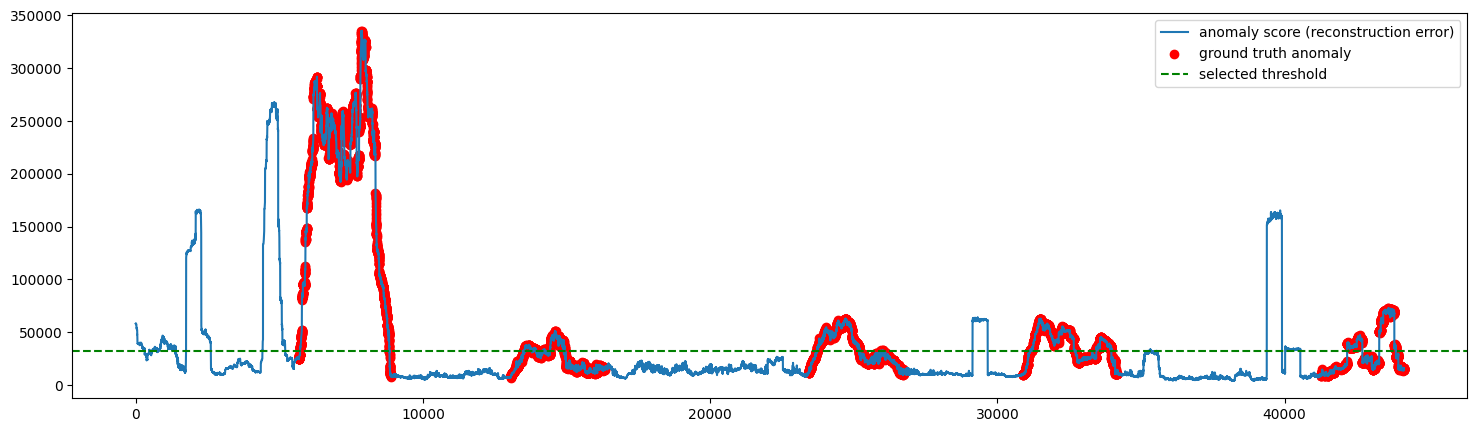

In [72]:
# Plot test_score, colored by ground truth. Draw threshold line
plt.figure(figsize=(18,5))
plt.plot(test_score, label='anomaly score (reconstruction error)')
plt.scatter(np.flatnonzero(test_labels_vae==1), test_score[test_labels_vae==1], color='r', label='ground truth anomaly')
plt.axhline(y=threshold, color='g', linestyle='--', label='selected threshold')
plt.legend()